# Trajectory analysis
50 ns NPT production MD 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mdtraj as md
import pytraj as pt

## (NG) Before "drying" trajectory in `cpptraj`
loaded files too large, RAM full

#### Without FSC

In [22]:
top_noFSC_mdin_path = '/home/wjoon21/project/chen2023_possible_allosteric/B2/trial7_cubic_temp_barostat/amber_o98_cubic_ion.parm7'
crd_noFSC_mdout_path = '/home/wjoon21/project/chen2023_possible_allosteric/B2/trial7_cubic_temp_barostat/o98_prod_md.nc'

In [23]:
traj_noFSC = pt.load(crd_noFSC_mdout_path, top=top_noFSC_mdin_path)
print(traj_noFSC)

pytraj.Trajectory, 2500 frames: 
Size: 4.843175 (GB)
<Topology: 86672 atoms, 20907 residues, 20615 mols, PBC with box type = orthorhombic>
           


Reference

In [28]:
ref_crd_noFSC_mdin_path = '/home/wjoon21/project/chen2023_possible_allosteric/B2/trial7_cubic_temp_barostat/amber_o98_cubic_ion.rst7'
ref_traj_noFSC = pt.load(ref_crd_noFSC_mdin_path, top=traj_noFSC.top)
print(ref_traj_noFSC)

pytraj.Trajectory, 1 frames: 
Size: 0.001937 (GB)
<Topology: 86672 atoms, 20907 residues, 20615 mols, PBC with box type = orthorhombic>
           


##### Larger protein (Chain 1)

In [24]:
rmsd_c1_noFSC = pt.rmsd(traj_noFSC, ref=0, mask=":1-242&!@H*")
print(rmsd_c1_noFSC, len(rmsd_c1_noFSC), sep='\n')

[7.38136505e-07 8.85992084e-01 1.06025035e+00 ... 2.46108510e+00
 2.58253224e+00 2.59072740e+00]
2500


Text(0, 0.5, 'RMSD (Angstrom)')

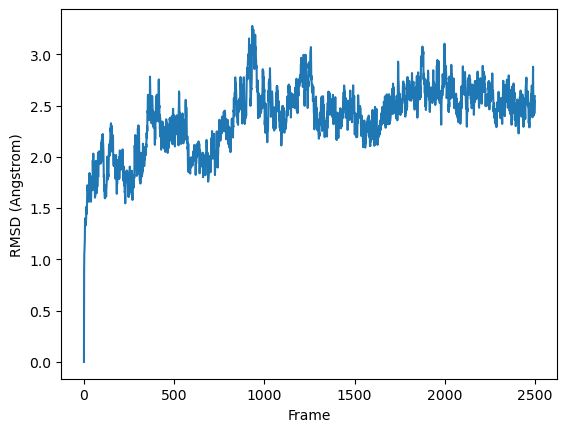

In [25]:
plt.plot(rmsd_c1_noFSC)
plt.xlabel('Frame')
plt.ylabel('RMSD (Angstrom)')

Compare to reference structure

In [30]:
rmsd_ref_c1_noFSC = pt.rmsd(traj_noFSC, ref=ref_traj_noFSC, mask=":1-242&!@H*")
print(rmsd_ref_c1_noFSC, len(rmsd_ref_c1_noFSC), sep='\n')

[1.96795391 2.12967033 2.0952514  ... 2.67424005 2.68838612 2.70961251]
2500


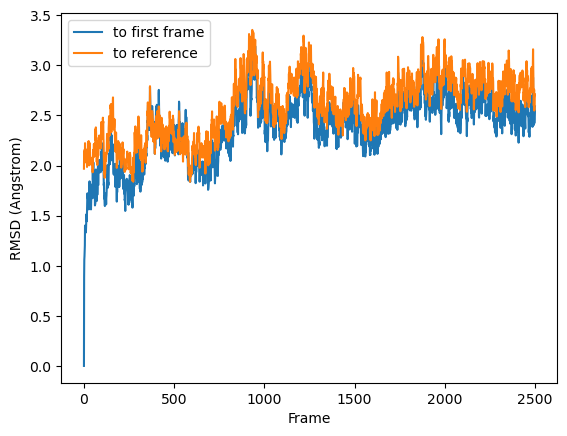

In [31]:
plt.plot(rmsd_c1_noFSC, label='to first frame')
plt.plot(rmsd_ref_c1_noFSC, label='to reference')
plt.xlabel('Frame')
plt.ylabel('RMSD (Angstrom)')
plt.legend()

##### Smaller protein (Chain 2)

In [26]:
rmsd_c2_noFSC = pt.rmsd(traj_noFSC, ref=0, mask=":243-294&!@H*")
print(rmsd_c2_noFSC, len(rmsd_c2_noFSC), sep='\n')

[5.31486928e-07 8.32267257e-01 1.04482333e+00 ... 3.58522686e+00
 3.49163647e+00 3.34761101e+00]
2500


Text(0, 0.5, 'RMSD (Angstrom)')

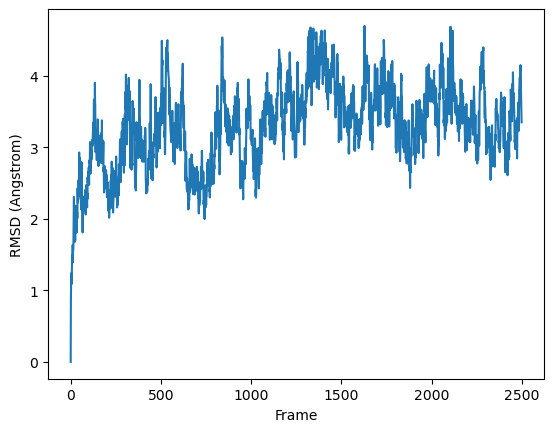

In [27]:
plt.plot(rmsd_c2_noFSC)
plt.xlabel('Frame')
plt.ylabel('RMSD (Angstrom)')

#### With FSC

In [32]:
top_mdin_path = '/home/wjoon21/project/chen2023_possible_allosteric/B2/trial9_param_FSC_terminal_finished/amber_o98_FSC_cubic_ion.parm7'
crd_mdout_path = '/home/wjoon21/project/chen2023_possible_allosteric/B2/trial9_param_FSC_terminal_finished/o98_FSC_prod_md.nc'

In [33]:
traj_FSC = pt.load(crd_mdout_path, top=top_mdin_path)
print(traj_FSC)

pytraj.Trajectory, 2500 frames: 
Size: 4.845187 (GB)
<Topology: 86708 atoms, 20891 residues, 20599 mols, PBC with box type = orthorhombic>
           


Reference

In [35]:
ref_crd_FSC_mdin_path = '/home/wjoon21/project/chen2023_possible_allosteric/B2/trial9_param_FSC_terminal_finished/amber_o98_FSC_cubic_ion.rst7'
ref_traj_FSC = pt.load(ref_crd_FSC_mdin_path, top=traj_FSC.top)
print(ref_traj_noFSC)

pytraj.Trajectory, 1 frames: 
Size: 0.001937 (GB)
<Topology: 86672 atoms, 20907 residues, 20615 mols, PBC with box type = orthorhombic>
           


##### Larger protein

In [38]:
rmsd_c1_FSC = pt.rmsd(traj_FSC, ref=0, mask=":1-242&!@H*")
print(rmsd_c1_FSC, len(rmsd_c1_FSC), sep='\n')

[6.95921771e-07 8.32870866e-01 9.72759059e-01 ... 4.20231907e+00
 4.27197578e+00 4.21253635e+00]
2500


Text(0, 0.5, 'RMSD (Angstrom)')

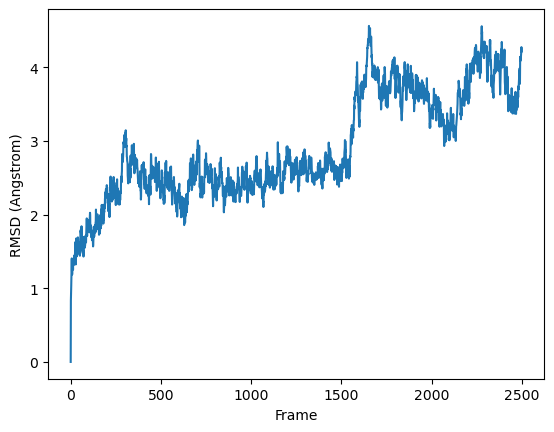

In [17]:
plt.plot(rmsd_c1_FSC)
plt.xlabel('Frame')
plt.ylabel('RMSD (Angstrom)')

Compare to reference structure

In [36]:
rmsd_ref_c1_FSC = pt.rmsd(traj_FSC, ref=ref_traj_FSC, mask=":1-242&!@H*")
print(rmsd_ref_c1_FSC, len(rmsd_ref_c1_FSC), sep='\n')

[1.85686578 1.88771895 1.90376719 ... 4.14941991 4.21750709 4.17257597]
2500


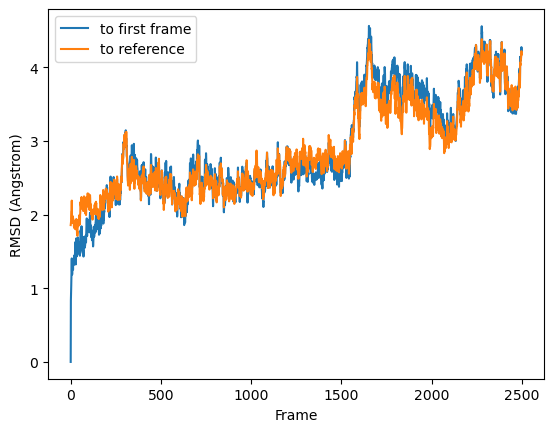

In [39]:
plt.plot(rmsd_c1_FSC, label='to first frame')
plt.plot(rmsd_ref_c1_FSC, label='to reference')
plt.xlabel('Frame')
plt.ylabel('RMSD (Angstrom)')
plt.legend()

##### Smaller protein

In [19]:
rmsd_smaller_protein = pt.rmsd(traj_fsc, ref=0, mask=":243-294&!@H*")
print(rmsd_smaller_protein, len(rmsd_smaller_protein), sep='\n')

[5.47355693e-07 8.85867094e-01 8.83456383e-01 ... 2.78224907e+00
 2.73065647e+00 2.73808078e+00]
2500


Text(0, 0.5, 'RMSD (Angstrom)')

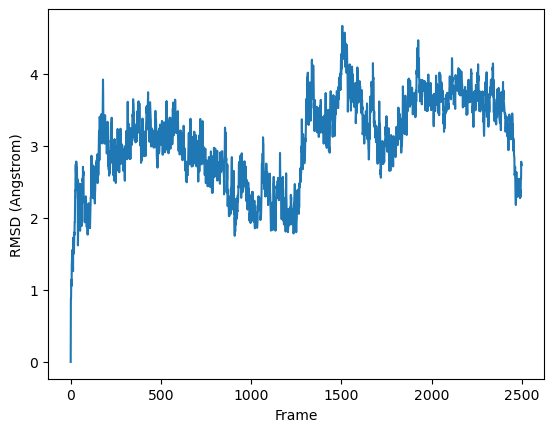

In [20]:
plt.plot(rmsd_smaller_protein)
plt.xlabel('Frame')
plt.ylabel('RMSD (Angstrom)')

## After "drying" trajectory in `cpptraj`

#### Strip water and ions

##### Without FSC

```sh
wjoon21@puma:~/project/chen2023_possible_allosteric/B2/trial7_cubic_temp_barostat$ cpptraj -p amber_o98_cubic_ion.parm7 -y o98_prod_md.nc 

CPPTRAJ: Trajectory Analysis. V6.4.4 (AmberTools)
    ___  ___  ___  ___
     | \/ | \/ | \/ | 
    _|_/\_|_/\_|_/\_|_

| Date/time: 06/26/24 15:04:48
| Available memory: 279.826 MB

        Reading 'amber_o98_cubic_ion.parm7' as Amber Topology
        Radius Set: modified Bondi radii (mbondi)
        Reading 'o98_prod_md.nc' as Amber NetCDF
        Loading previous history from log 'cpptraj.log'
> strip :WAT,Na+,Cl- parmout cpptraj_o98_dry.parm7        
  [strip :WAT,Na+,Cl- parmout cpptraj_o98_dry.parm7]
    STRIP: Stripping atoms in mask [:WAT,Na+,Cl-]
        Writing 'stripped' topology file with name 'cpptraj_o98_dry.parm7'
> trajout cpptraj_o98_dry.nc       
  [trajout cpptraj_o98_dry.nc]
        Writing 'cpptraj_o98_dry.nc' as Amber NetCDF
> go
  [go]
---------- RUN BEGIN -------------------------------------------------

PARAMETER FILES (1 total):
 0: amber_o98_cubic_ion.parm7, 86672 atoms, 20907 res, box: Orthorhombic, 20615 mol, 20457 solvent

INPUT TRAJECTORIES (1 total):
 0: 'o98_prod_md.nc' is a NetCDF AMBER trajectory with coordinates, time, box, Parm amber_o98_cubic_ion.parm7 (Orthorhombic box) (reading 2500 of 2500)
  Coordinate processing will occur on 2500 frames.

OUTPUT TRAJECTORIES (1 total):
  'cpptraj_o98_dry.nc' (2500 frames) is a NetCDF AMBER trajectory

BEGIN TRAJECTORY PROCESSING:
.....................................................
ACTION SETUP FOR PARM 'amber_o98_cubic_ion.parm7' (1 actions):
  0: [strip :WAT,Na+,Cl- parmout cpptraj_o98_dry.parm7]
        Stripping 81984 atoms.
        Stripped topology: 4688 atoms, 294 res, box: Orthorhombic, 2 mol
        Writing topology 0 (amber_o98_cubic_ion.parm7) to 'cpptraj_o98_dry.parm7' with format Amber Topology
        Memory used by full exclusion list: 102.248 kB
.....................................................
ACTIVE OUTPUT TRAJECTORIES (1):
  cpptraj_o98_dry.nc (coordinates, time, box)
----- o98_prod_md.nc (1-2500, 1) -----
 0% 10% 20% 30% 40% 50% 60% 70% 80% 90% 100% Complete.

Read 2500 frames and processed 2500 frames.
TIME: Avg. throughput= 168.3815 frames / second.

ACTION OUTPUT:
TIME: Analyses took 0.0000 seconds.

RUN TIMING:
TIME:           Init               : 0.0001 s (  0.00%)
TIME:           Trajectory Process : 14.8472 s (100.00%)
TIME:           Action Post        : 0.0000 s (  0.00%)
TIME:           Analysis           : 0.0000 s (  0.00%)
TIME:           Data File Write    : 0.0000 s (  0.00%)
TIME:           Other              : 0.0003 s (  0.00%)
TIME:   Run Total 14.8477 s
---------- RUN END ---------------------------------------------------
> quit
  [quit]
--------------------------------------------------------------------------------
To cite CPPTRAJ use:
Daniel R. Roe and Thomas E. Cheatham, III, "PTRAJ and CPPTRAJ: Software for
  Processing and Analysis of Molecular Dynamics Trajectory Data". J. Chem.
  Theory Comput., 2013, 9 (7), pp 3084-3095.
```

##### With FSC

```sh
wjoon21@puma:~/project/chen2023_possible_allosteric/B2/trial9_param_FSC_terminal_finished$ cpptraj -p amber_o98_FSC_cubic_ion.parm7 -y o98_FSC_prod_md.nc

CPPTRAJ: Trajectory Analysis. V6.4.4 (AmberTools)
    ___  ___  ___  ___
     | \/ | \/ | \/ | 
    _|_/\_|_/\_|_/\_|_

| Date/time: 06/26/24 15:22:13
| Available memory: 214.626 MB

        Reading 'amber_o98_FSC_cubic_ion.parm7' as Amber Topology
        Radius Set: modified Bondi radii (mbondi)
        Reading 'o98_FSC_prod_md.nc' as Amber NetCDF
> strip :WAT,Na+,Cl- parmout o98_FSC_dry.parm7    
  [strip :WAT,Na+,Cl- parmout o98_FSC_dry.parm7]
    STRIP: Stripping atoms in mask [:WAT,Na+,Cl-]
        Writing 'stripped' topology file with name 'o98_FSC_dry.parm7'
> trajout o98_FSC_dry.nc           
  [trajout o98_FSC_dry.nc]
        Writing 'o98_FSC_dry.nc' as Amber NetCDF
> go
  [go]
---------- RUN BEGIN -------------------------------------------------

PARAMETER FILES (1 total):
 0: amber_o98_FSC_cubic_ion.parm7, 86708 atoms, 20891 res, box: Orthorhombic, 20599 mol, 20440 solvent

INPUT TRAJECTORIES (1 total):
 0: 'o98_FSC_prod_md.nc' is a NetCDF AMBER trajectory with coordinates, time, box, Parm amber_o98_FSC_cubic_ion.parm7 (Orthorhombic box) (reading 2500 of 2500)
  Coordinate processing will occur on 2500 frames.

OUTPUT TRAJECTORIES (1 total):
  'o98_FSC_dry.nc' (2500 frames) is a NetCDF AMBER trajectory

BEGIN TRAJECTORY PROCESSING:
.....................................................
ACTION SETUP FOR PARM 'amber_o98_FSC_cubic_ion.parm7' (1 actions):
  0: [strip :WAT,Na+,Cl- parmout o98_FSC_dry.parm7]
        Stripping 81916 atoms.
        Stripped topology: 4792 atoms, 295 res, box: Orthorhombic, 3 mol
        Writing topology 0 (amber_o98_FSC_cubic_ion.parm7) to 'o98_FSC_dry.parm7' with format Amber Topology
        Memory used by full exclusion list: 104.624 kB
.....................................................
ACTIVE OUTPUT TRAJECTORIES (1):
  o98_FSC_dry.nc (coordinates, time, box)
----- o98_FSC_prod_md.nc (1-2500, 1) -----
 0% 10% 20% 30% 40% 50% 60% 70% 80% 90% 100% Complete.

Read 2500 frames and processed 2500 frames.
TIME: Avg. throughput= 155.7654 frames / second.

ACTION OUTPUT:
TIME: Analyses took 0.0000 seconds.

RUN TIMING:
TIME:           Init               : 0.0001 s (  0.00%)
TIME:           Trajectory Process : 16.0498 s (100.00%)
TIME:           Action Post        : 0.0000 s (  0.00%)
TIME:           Analysis           : 0.0000 s (  0.00%)
TIME:           Data File Write    : 0.0000 s (  0.00%)
TIME:           Other              : 0.0004 s (  0.00%)
TIME:   Run Total 16.0503 s
---------- RUN END ---------------------------------------------------
> quit
  [quit]
--------------------------------------------------------------------------------
To cite CPPTRAJ use:
Daniel R. Roe and Thomas E. Cheatham, III, "PTRAJ and CPPTRAJ: Software for
  Processing and Analysis of Molecular Dynamics Trajectory Data". J. Chem.
  Theory Comput., 2013, 9 (7), pp 3084-3095.
```

#### Load trajectories stripped of water and ions

##### FSC$^{+}$

In [2]:
top_FSC_dry_path = '/home/wjoon21/project/chen2023_possible_allosteric/B2/trial9_param_FSC_terminal_finished/cpptraj_o98_FSC_dry.parm7'
crd_FSC_dry_path = '/home/wjoon21/project/chen2023_possible_allosteric/B2/trial9_param_FSC_terminal_finished/cpptraj_o98_FSC_dry.nc'

traj_FSC_dry = pt.load(crd_FSC_dry_path, top=top_FSC_dry_path)
print(traj_FSC_dry)

pytraj.Trajectory, 2500 frames: 
Size: 0.267774 (GB)
<Topology: 4792 atoms, 295 residues, 3 mols, PBC with box type = orthorhombic>
           


##### FSC$^{-}$

In [4]:
top_noFSC_dry_path = 'B2/trial7_cubic_temp_barostat/amber_o98_dry.parm7'
crd_noFSC_dry_path = 'B2/trial7_cubic_temp_barostat/amber_o98_prod_dry.nc'

traj_noFSC_dry = pt.load(crd_noFSC_dry_path, top=top_noFSC_dry_path)
print(traj_noFSC_dry)

pytraj.Trajectory, 2500 frames: 
Size: 0.261962 (GB)
<Topology: 4688 atoms, 294 residues, 2 mols, PBC with box type = orthorhombic>
           


### (NG) RMSD of whole complex (without hydrogen)

In [5]:
rmsd_complex_noFSC_dry = pt.rmsd(traj_noFSC_dry, ref=0, mask="!@H*")
print(rmsd_complex_noFSC_dry, len(rmsd_complex_noFSC_dry), sep='\n')

[1.09084149e-06 8.94557367e-01 1.06767025e+00 ... 3.28021877e+00
 3.33097853e+00 3.42474847e+00]
2500


In [10]:
rmsd_complex_FSC_dry = pt.rmsd(traj_FSC_dry, ref=0, mask="!@H*")
print(rmsd_complex_FSC_dry, len(rmsd_complex_FSC_dry), sep='\n')

[1.63471862e-06 8.63589430e-01 9.85309838e-01 ... 4.52758731e+00
 4.58037396e+00 4.51370289e+00]
2500


Text(0, 0.5, 'RMSD (Å)')

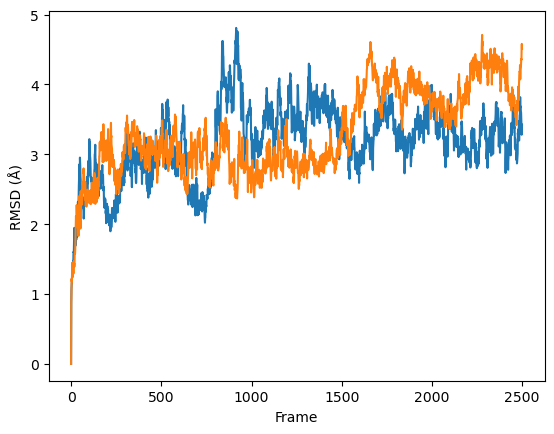

In [11]:
plt.plot(rmsd_complex_noFSC_dry)
plt.plot(rmsd_complex_FSC_dry)
plt.xlabel('Frame')
plt.ylabel('RMSD (Å)')

With FSC (orange) is more flexible?!

### RMSD of interface atoms (without H)

#### Whole complex interface

In [17]:
# List of atom indices
atom_indices = [870, 879, 979, 982, 988, 990, 994, 1046, 1048, 1051, 1054, 1057, 1059, 1060, 1063, 1078, 1081, 1119, 1121, 1124, 1130, 1169, 1183, 2055, 2172, 2173, 2176, 2861, 2875, 2876, 2916, 2918, 2922, 3001, 3533, 3556, 3583, 3586, 3589, 3591, 3603, 3609, 3662, 3667, 3678, 3746, 4135, 4138, 4182, 4205, 4211, 4260, 4261, 4288, 4297, 4353, 4355, 4359, 4413, 4506, 4534, 4537, 4553, 4554, 4555, 4585, 4618, 4619, 4620, 4632, 4638, 4640, 4643, 4644, 4646, 4659, 4661, 4664, 4665, 4666, 4673, 4675, 4682, 4688]

# Create the mask string
interface_atom_index = ",".join(f"@{i}" for i in atom_indices)

rmsd_complex_noFSC_dry_interface = pt.rmsd(traj_noFSC_dry, ref=0, mask=f"{interface_atom_index}&!@H*")
print(rmsd_complex_noFSC_dry_interface, len(rmsd_complex_noFSC_dry_interface), sep='\n')

rmsd_complex_FSC_dry_interface = pt.rmsd(traj_FSC_dry, ref=0, mask=f"{interface_atom_index}&!@H*")
print(rmsd_complex_FSC_dry_interface, len(rmsd_complex_FSC_dry_interface), sep='\n')

[0.         0.67697866 0.77729832 ... 2.93362402 3.0217079  2.90459793]
2500
[0.         0.7221774  0.76169602 ... 1.75639967 1.75649996 1.81536744]
2500


##### (NG) `matplotlib`

Text(0, 0.5, 'RMSD (Å)')

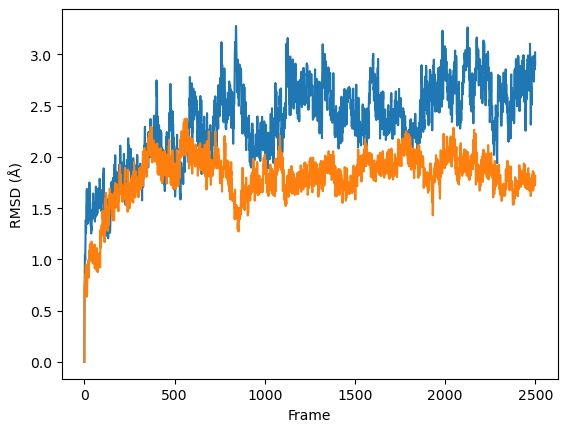

In [18]:
plt.plot(rmsd_complex_noFSC_dry_interface)
plt.plot(rmsd_complex_FSC_dry_interface)
plt.xlabel('Frame')
plt.ylabel('RMSD (Å)')

##### `seaborn`
Instead of "Frame", show "Time" on _x_-axis by using DataFrame

In [25]:
print(traj_FSC_dry.time, len(traj_FSC_dry.time), sep='\n')

[ 4020.  4040.  4060. ... 53960. 53980. 54000.]
2500


In [28]:
rmsd_traj_noFSC_dry_df = pd.DataFrame({'Time (ps)': traj_noFSC_dry.time, 'RMSD (Å)': rmsd_complex_noFSC_dry_interface})
display(rmsd_traj_noFSC_dry_df)

,Time (ps),RMSD (Å)
0,4020.0,0.000000
1,4040.0,0.676979
2,4060.0,0.777298
3,4080.0,1.038405
4,4100.0,1.031862
...,...,...
2495,53920.0,2.850687
2496,53940.0,2.932954
2497,53960.0,2.933624
2498,53980.0,3.021708


In [29]:
rmsd_traj_FSC_dry_df = pd.DataFrame({'Time (ps)': traj_FSC_dry.time, 'RMSD (Å)': rmsd_complex_FSC_dry_interface})
display(rmsd_traj_FSC_dry_df)

,Time (ps),RMSD (Å)
0,4020.0,0.000000
1,4040.0,0.722177
2,4060.0,0.761696
3,4080.0,0.795649
4,4100.0,0.800035
...,...,...
2495,53920.0,1.718640
2496,53940.0,1.764287
2497,53960.0,1.756400
2498,53980.0,1.756500


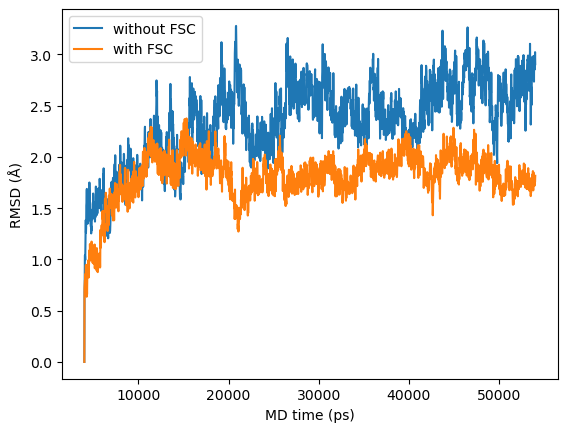

In [33]:
sns.lineplot(data=rmsd_traj_noFSC_dry_df, x="Time (ps)", y="RMSD (Å)", label='without FSC')
sns.lineplot(data=rmsd_traj_FSC_dry_df, x="Time (ps)", y="RMSD (Å)", label='with FSC')

plt.xlabel("MD time (ps)")
plt.ylabel("RMSD (Å)")
plt.legend(loc='best')

plt.savefig("RMSD_time_2o98_FSC.png", format='png', dpi=300)

plt.show()

#### Receptor interface

In [6]:
# List of atom indices
Rint_atom_indicesList = [870,  879,  979,  982,  988,  990,  994, 1046, 1048, 1051, 
                         1054, 1057, 1059, 1060, 1063, 1078, 1081, 1119, 1121, 1124, 
                         1130, 1169, 1183, 2055, 2172, 2173, 2176, 2861, 2875, 2876, 
                         2916, 2918, 2922, 3001, 3533, 3556, 3583, 3586, 3589, 3591, 
                         3603, 3609, 3662, 3667, 3678, 3746]

# Create the mask string
Rint_atom_indicesStr = ",".join(f"@{i}" for i in Rint_atom_indicesList)
print(Rint_atom_indicesStr)

@870,@879,@979,@982,@988,@990,@994,@1046,@1048,@1051,@1054,@1057,@1059,@1060,@1063,@1078,@1081,@1119,@1121,@1124,@1130,@1169,@1183,@2055,@2172,@2173,@2176,@2861,@2875,@2876,@2916,@2918,@2922,@3001,@3533,@3556,@3583,@3586,@3589,@3591,@3603,@3609,@3662,@3667,@3678,@3746


##### FSC$^{+}$

In [7]:
rmsd_Rint_FSC_array = pt.rmsd(traj_FSC_dry, ref=0, mask=f"{Rint_atom_indicesStr}&!@H*")
print(rmsd_Rint_FSC_array, len(rmsd_Rint_FSC_array), sep='\n')

[0.         0.58142046 0.54624513 ... 1.65870317 1.60093177 1.59857506]
2500


In [10]:
rmsd_time_Rint_FSC_df = pd.DataFrame({'Time (ps)': traj_FSC_dry.time, 'RMSD (Å)': rmsd_Rint_FSC_array})
display(rmsd_time_Rint_FSC_df)

,Time (ps),RMSD (Å)
0,4020.0,0.000000
1,4040.0,0.581420
2,4060.0,0.546245
3,4080.0,0.524277
4,4100.0,0.482640
...,...,...
2495,53920.0,1.618138
2496,53940.0,1.600469
2497,53960.0,1.658703
2498,53980.0,1.600932


##### FSC$^{-}$

In [8]:
rmsd_Rint_noFSC_array = pt.rmsd(traj_noFSC_dry, ref=0, mask=f"{Rint_atom_indicesStr}&!@H*")
print(rmsd_Rint_noFSC_array, len(rmsd_Rint_noFSC_array), sep='\n')

[0.         0.71613859 0.77513189 ... 1.83843218 1.90799108 1.93856269]
2500


In [11]:
rmsd_time_Rint_noFSC_df = pd.DataFrame({'Time (ps)': traj_noFSC_dry.time, 'RMSD (Å)': rmsd_Rint_noFSC_array})
display(rmsd_time_Rint_noFSC_df)

,Time (ps),RMSD (Å)
0,4020.0,0.000000
1,4040.0,0.716139
2,4060.0,0.775132
3,4080.0,0.935411
4,4100.0,1.061729
...,...,...
2495,53920.0,2.012931
2496,53940.0,1.943290
2497,53960.0,1.838432
2498,53980.0,1.907991


Plots to see RMSD

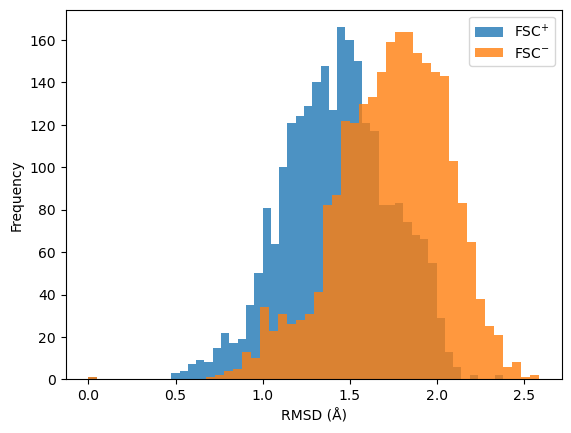

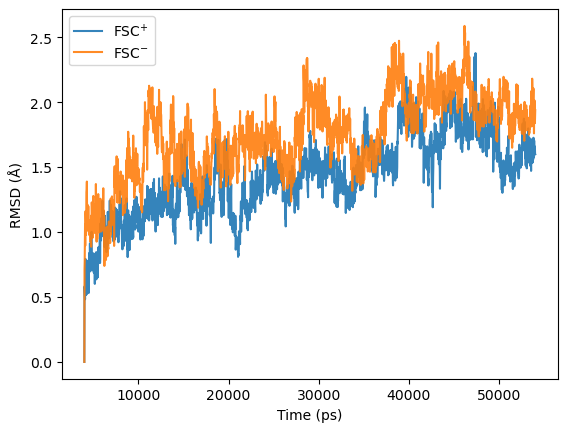

In [17]:
sns.histplot(rmsd_time_Rint_FSC_df['RMSD (Å)'], bins=50, label='FSC$^{+}$', alpha=0.8, edgecolor='none')
sns.histplot(rmsd_time_Rint_noFSC_df['RMSD (Å)'], bins=50, label='FSC$^{-}$', alpha=0.8, edgecolor='none')

plt.xlabel("RMSD (Å)")
plt.ylabel("Frequency")
plt.legend(loc='best')

plt.show()

sns.lineplot(data=rmsd_time_Rint_FSC_df, x="Time (ps)", y="RMSD (Å)", label='FSC$^{+}$', alpha=0.9)
sns.lineplot(data=rmsd_time_Rint_noFSC_df, x="Time (ps)", y="RMSD (Å)", label='FSC$^{-}$', alpha=0.9)

plt.xlabel("Time (ps)")
plt.ylabel("RMSD (Å)")
plt.legend(loc='best')

plt.show()

### Root-mean square fluctuation (RMSF)
average RMSD over all frames (_y_) vs atom index (_x_)

#### Whole complex residues

In [21]:
rmsf_complex_noFSC_dry = pt.rmsf(traj_noFSC_dry)
print(rmsf_complex_noFSC_dry, len(rmsf_complex_noFSC_dry), sep='\n')

rmsf_complex_FSC_dry = pt.rmsf(traj_FSC_dry)
print(rmsf_complex_FSC_dry, len(rmsf_complex_FSC_dry), sep='\n')

[[1.00000000e+00 1.01881536e+01]
 [2.00000000e+00 1.03757236e+01]
 [3.00000000e+00 1.03939040e+01]
 ...
 [4.68600000e+03 5.56556212e-01]
 [4.68700000e+03 1.14308975e+00]
 [4.68800000e+03 1.11045236e+00]]
4688
[[1.00000000e+00 1.26708179e+01]
 [2.00000000e+00 1.28664085e+01]
 [3.00000000e+00 1.28986399e+01]
 ...
 [4.79000000e+03 7.25761586e-01]
 [4.79100000e+03 8.67046548e-01]
 [4.79200000e+03 6.60344954e-01]]
4792


In [1]:
4792-4688

104

i.e., FSC accounts for 104 "extra" atoms\
which is at the end (PDB), so there is no problem with comparing protein RMSFs

Text(0, 0.5, 'RMSF (Å)')

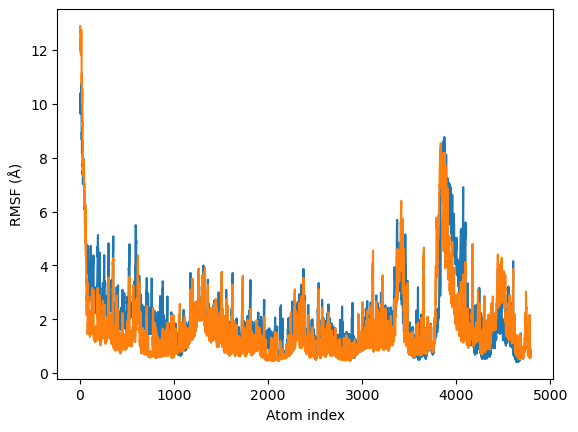

In [22]:
plt.plot(rmsf_complex_noFSC_dry.T[0], rmsf_complex_noFSC_dry.T[1])
plt.plot(rmsf_complex_FSC_dry.T[0], rmsf_complex_FSC_dry.T[1])
plt.xlabel('Atom index')
plt.ylabel('RMSF (Å)')

#### receptor interface residues

##### FSC$^{+}$

In [18]:
rmsf_Rint_FSC_array = pt.rmsf(traj_FSC_dry, mask=f"{Rint_atom_indicesStr}&!@H*")
print(rmsf_Rint_FSC_array, len(rmsf_Rint_FSC_array), sep='\n')

[[8.70000000e+02 6.69556272e-01]
 [8.79000000e+02 1.23081123e+00]
 [9.79000000e+02 5.19631797e-01]
 ...
 [3.66700000e+03 1.20691059e+00]
 [3.67800000e+03 5.57597795e-01]
 [3.74600000e+03 8.47835710e-01]]
46


In [58]:
rmsf_Rint_FSC_df = pd.DataFrame(rmsf_Rint_FSC_array, columns=['Atom index', 'RMSF (Å)'])
rmsf_Rint_FSC_df['Atom index'] = rmsf_Rint_FSC_df['Atom index'].astype(int)
display(rmsf_Rint_FSC_df)

,Atom index,RMSF (Å)
0,870,0.669556
1,879,1.230811
2,979,0.519632
3,982,0.581381
4,988,1.224538
5,990,1.320982
6,994,1.734844
7,1046,0.628813
8,1048,0.682342
9,1051,1.182115


##### FSC$^{-}$

In [19]:
rmsf_Rint_noFSC_array = pt.rmsf(traj_noFSC_dry, mask=f"{Rint_atom_indicesStr}&!@H*")
print(rmsf_Rint_noFSC_array, len(rmsf_Rint_noFSC_array), sep='\n')

[[8.70000000e+02 1.71377165e+00]
 [8.79000000e+02 2.87178443e+00]
 [9.79000000e+02 7.74991229e-01]
 ...
 [3.66700000e+03 1.72856888e+00]
 [3.67800000e+03 5.75044145e-01]
 [3.74600000e+03 7.68309794e-01]]
46


In [59]:
rmsf_Rint_noFSC_df = pd.DataFrame(rmsf_Rint_noFSC_array, columns=['Atom index', 'RMSF (Å)'])
rmsf_Rint_noFSC_df['Atom index'] = rmsf_Rint_noFSC_df['Atom index'].astype(int)
display(rmsf_Rint_noFSC_df)

,Atom index,RMSF (Å)
0,870,1.713772
1,879,2.871784
2,979,0.774991
3,982,0.750453
4,988,0.668259
5,990,0.887269
6,994,1.165556
7,1046,0.559822
8,1048,0.587002
9,1051,0.619522


##### Plot RMSF

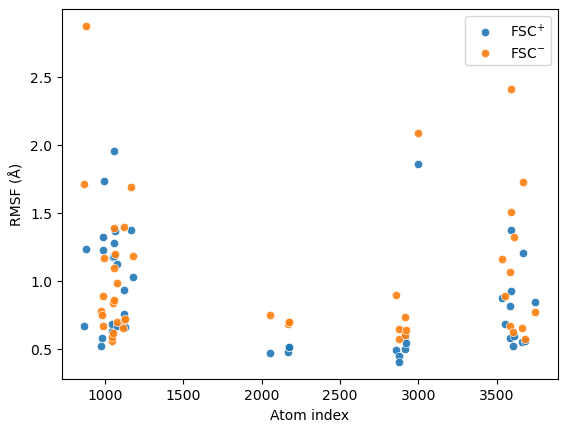

In [60]:
sns.scatterplot(data=rmsf_Rint_FSC_df, x='Atom index', y='RMSF (Å)', label='FSC$^{+}$', alpha=0.9)
sns.scatterplot(data=rmsf_Rint_noFSC_df, x='Atom index', y='RMSF (Å)', label='FSC$^{-}$', alpha=0.9)

plt.xlabel("Atom index")
plt.ylabel("RMSF (Å)")
plt.legend(loc='best')

plt.show()

$\rightarrow$ too dense

Create a mapping of 'Atom index' to equally spaced values

In [62]:
unique_atoms = rmsf_Rint_FSC_df['Atom index'].unique()
print(unique_atoms)

atom_mapping = {atom: i for i, atom in enumerate(unique_atoms)}
print(atom_mapping)

[ 870  879  979 ... 3667 3678 3746]
{870: 0, 879: 1, 979: 2, 982: 3, 988: 4, 990: 5, 994: 6, 1046: 7, 1048: 8, 1051: 9, 1054: 10, 1057: 11, 1059: 12, 1060: 13, 1063: 14, 1078: 15, 1081: 16, 1119: 17, 1121: 18, 1124: 19, 1130: 20, 1169: 21, 1183: 22, 2055: 23, 2172: 24, 2173: 25, 2176: 26, 2861: 27, 2875: 28, 2876: 29, 2916: 30, 2918: 31, 2922: 32, 3001: 33, 3533: 34, 3556: 35, 3583: 36, 3586: 37, 3589: 38, 3591: 39, 3603: 40, 3609: 41, 3662: 42, 3667: 43, 3678: 44, 3746: 45}


Apply the mapping to the 'Residue index' column

In [63]:
rmsf_Rint_FSC_mapdf = rmsf_Rint_FSC_df.copy()
rmsf_Rint_FSC_mapdf['Atom index'] = rmsf_Rint_FSC_mapdf['Atom index'].map(residue_mapping)
display(rmsf_Rint_FSC_mapdf)

rmsf_Rint_noFSC_mapdf = rmsf_Rint_noFSC_df.copy()
rmsf_Rint_noFSC_mapdf['Atom index'] = rmsf_Rint_noFSC_mapdf['Atom index'].map(residue_mapping)
display(rmsf_Rint_noFSC_mapdf)

,Atom index,RMSF (Å)
0,0,0.669556
1,1,1.230811
2,2,0.519632
3,3,0.581381
4,4,1.224538
5,5,1.320982
6,6,1.734844
7,7,0.628813
8,8,0.682342
9,9,1.182115


,Atom index,RMSF (Å)
0,0,1.713772
1,1,2.871784
2,2,0.774991
3,3,0.750453
4,4,0.668259
5,5,0.887269
6,6,1.165556
7,7,0.559822
8,8,0.587002
9,9,0.619522


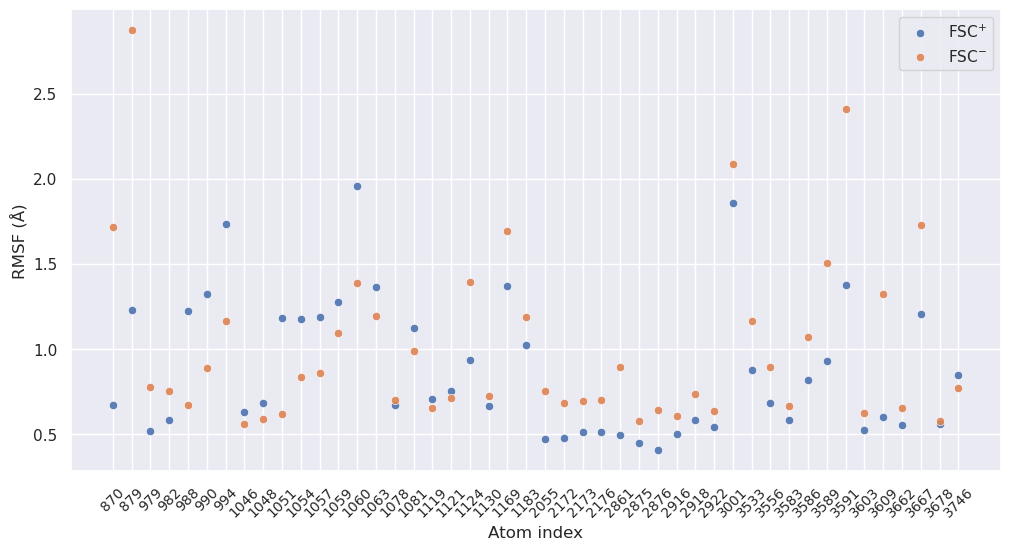

In [97]:
sns.set_style("darkgrid")
# sns.set(rc={'axes.facecolor':'lightgrey', 'figure.facecolor':'white'})

plt.figure(figsize=(12, 6))

sns.scatterplot(data=rmsf_Rint_FSC_mapdf, x='Atom index', y='RMSF (Å)', label='FSC$^{+}$', alpha=0.9)
sns.scatterplot(data=rmsf_Rint_noFSC_mapdf, x='Atom index', y='RMSF (Å)', label='FSC$^{-}$', alpha=0.9)

plt.xlabel("Atom index")
plt.ylabel("RMSF (Å)")
plt.legend(loc='best')

# Set the x-ticks to be equal to the data points
plt.xticks(np.arange(len(unique_residues)), unique_residues, rotation=45, fontsize=10)

plt.show()

Text(0, 0.5, 'RMSF (Å)')

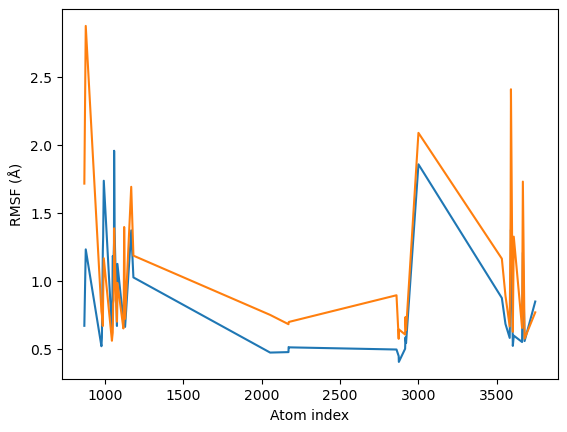

In [20]:
plt.plot(rmsf_Rint_FSC_array.T[0], rmsf_Rint_FSC_array.T[1])
plt.plot(rmsf_Rint_noFSC_array.T[0], rmsf_Rint_noFSC_array.T[1])
plt.xlabel('Atom index')
plt.ylabel('RMSF (Å)')

##### get residues of most variable atoms (function in `07_.ipynb`) $\rightarrow$ observe in VMD

In [69]:
def get_residue_index_and_atoms(file, interface_atom_indices):
    atoms_in_residue = []
    residue_numbers = []

    with open(file) as f:
        for line in f:
            fields = line.split()
            if fields[0] == "ATOM":
                atom_index = int(fields[1])
                residue_number = int(fields[4])

                if atom_index in interface_atom_indices:
                    residue_numbers.append(residue_number)

                if residue_number in residue_numbers:
                    atoms_in_residue.append(atom_index)

    return residue_numbers, atoms_in_residue

In [71]:
path2_2o98_tleap_pdb = 'B2/trial7_cubic_temp_barostat/amber_o98_preMin_dry.pdb'

Rint_resid_indicesList, Rint_resid_atom_indicesList = get_residue_index_and_atoms(path2_2o98_tleap_pdb, Rint_atom_indicesList)

print(Rint_resid_indicesList)

print(Rint_resid_atom_indicesList)

[56, 56, 63, 63, 63, 63, 63, 67, 67, 67, 67, 67, 67, 67, 67, 68, 68, 71, 71, 71, 72, 74, 75, 129, 136, 136, 136, 181, 182, 182, 185, 185, 185, 189, 225, 226, 228, 228, 228, 228, 229, 229, 232, 232, 233, 237]
[870, 871, 872, 873, 874, 875, 876, 877, 878, 879, 880, 881, 882, 883, 884, 979, 980, 981, 982, 983, 984, 985, 986, 987, 988, 989, 990, 991, 992, 993, 994, 995, 996, 997, 998, 1046, 1047, 1048, 1049, 1050, 1051, 1052, 1053, 1054, 1055, 1056, 1057, 1058, 1059, 1060, 1061, 1062, 1063, 1064, 1065, 1066, 1067, 1078, 1079, 1080, 1081, 1082, 1083, 1084, 1085, 1086, 1119, 1120, 1121, 1122, 1123, 1124, 1125, 1126, 1127, 1130, 1131, 1132, 1133, 1134, 1135, 1136, 1137, 1138, 1139, 1140, 1141, 1142, 1143, 1144, 1145, 1146, 1169, 1170, 1171, 1172, 1173, 1174, 1175, 1176, 1177, 1178, 1183, 1184, 1185, 1186, 1187, 1188, 1189, 1190, 1191, 1192, 1193, 1194, 1195, 1196, 1197, 1198, 1199, 1200, 2055, 2056, 2057, 2058, 2059, 2060, 2172, 2173, 2174, 2175, 2176, 2177, 2178, 2179, 2180, 2861, 2862, 2863

### (NG?) Principal component analysis

##### Without FSC

In [9]:
pca_noFSC = pt.pca(traj_noFSC_dry, mask='!@H=', n_vecs=2)
print('projection values of each frame to first mode = {} \n'.format(pca_noFSC[0][0]))
print('projection values of each frame to second mode = {} \n'.format(pca_noFSC[0][1]))
print('eigvenvalues of first two modes', pca_noFSC[1][0])
print("")
print('eigvenvectors of first two modes: \n', pca_noFSC[1][1])

projection values of each frame to first mode = [ -6.157435   -6.2418666  -4.524889  ... -34.251114  -28.113659
 -20.281166 ] 

projection values of each frame to second mode = [-73.42707  -72.19625  -71.95722  ...  17.634254  22.633848  25.74804 ] 

eigvenvalues of first two modes [2633.91506619 1890.27846186]

eigvenvectors of first two modes: 
 [[ 0.0549315  -0.04828133 -0.00965011 ...  0.00330938  0.00261347
   0.0002045 ]
 [ 0.08045826 -0.0459629  -0.03523796 ... -0.00262351 -0.0113462
   0.00861954]]


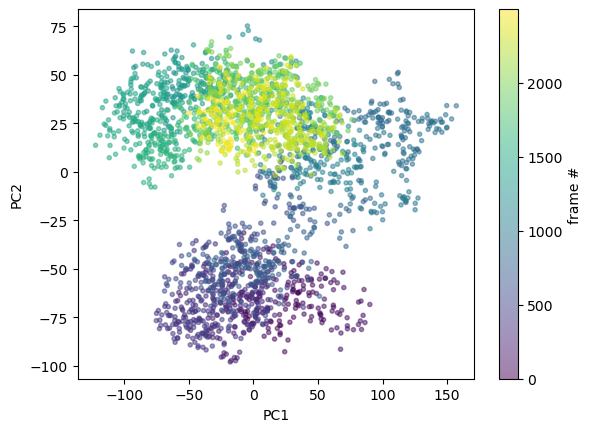

In [11]:
proj_pca_noFSC = pca_noFSC[0]
plt.scatter(proj_pca_noFSC[0], proj_pca_noFSC[1], marker='.', c=range(traj_noFSC_dry.n_frames), alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
cbar = plt.colorbar()
cbar.set_label('frame #')

##### With FSC

In [12]:
pca_FSC = pt.pca(traj_FSC_dry, mask='!@H=', n_vecs=2)
print('projection values of each frame to first mode = {} \n'.format(pca_FSC[0][0]))
print('projection values of each frame to second mode = {} \n'.format(pca_FSC[0][1]))
print('eigvenvalues of first two modes', pca_FSC[1][0])
print("")
print('eigvenvectors of first two modes: \n', pca_FSC[1][1])

projection values of each frame to first mode = [ 62.449806  61.790344  59.505817 ... -75.6854   -79.14336  -77.96988 ] 

projection values of each frame to second mode = [ 35.158455  38.50742   33.675156 ... -22.294882 -26.739008 -28.335808] 

eigvenvalues of first two modes [3084.40200823 1249.92756382]

eigvenvectors of first two modes: 
 [[-8.13918420e-02  1.36777002e-01 -1.42295100e-02 ...  3.83329030e-03
  -2.41758086e-05  1.42696725e-03]
 [-6.38087761e-02  3.15057776e-02 -7.06878954e-02 ...  4.33494714e-03
  -3.58627756e-03  3.11906368e-03]]


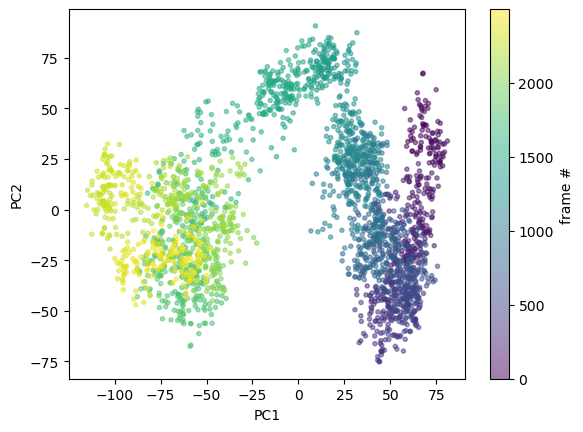

In [13]:
proj_pca_FSC = pca_FSC[0]
plt.scatter(proj_pca_FSC[0], proj_pca_FSC[1], marker='.', c=range(traj_FSC_dry.n_frames), alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
cbar = plt.colorbar()
cbar.set_label('frame #')

## `MDAnalysis`

In [6]:
import MDAnalysis as mda
import nglview as nv

In [7]:
univ_noFSC = mda.Universe(top_noFSC_dry_path, crd_noFSC_dry_path)
print(univ_noFSC)

<Universe with 4688 atoms>


In [8]:
univ_FSC = mda.Universe(top_FSC_dry_path, crd_FSC_dry_path)
print(univ_FSC)

<Universe with 4792 atoms>


#### RMSD

In [6]:
import pandas as pd
from MDAnalysis.analysis import rms

In [7]:
bb = u.select_atoms('backbone')

u.trajectory[0] # first frame
first = bb.positions

u.trajectory[-1] #last frame
last = bb.positions

rms.rmsd(first, last)

37.746560683526546

#### PCA

In [ ]:
from MDAnalysis.analysis import pca, align